# Feature Engineering y Experimentos A/B

## Configuración

In [1]:
import warnings, os, json, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc, silhouette_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

MODELOS = ['Random Forest', 'XGBoost']
MODEL_COLORS = {'Random Forest': 'red', 'XGBoost': 'purple'}
# familias de color por experimento: RF calidos, XGB frios (E1 claro -> E4 oscuro)
EXP_COLORS = {
    'Random Forest': ['lightcoral', 'salmon', 'crimson', 'darkred'],
    'XGBoost':       ['lavender', 'orchid', 'mediumpurple', 'indigo'],
}

df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']   # sin Au, sin coordenadas
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

SPW = float((y_train == 0).sum() / (y_train == 1).sum())
os.makedirs('outputs_sprint2', exist_ok=True)
print(f'Features base (elementos sin Au): {len(FEATURES_BASE)} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'scale_pos_weight (neg/pos en train) = {SPW:.2f}')
print('Punto de partida (Sprint 1): RF + SMOTE → F1 = 0.713')

Features base (elementos sin Au): 46 | Train: (1705, 46) | Test: (427, 46)
scale_pos_weight (neg/pos en train) = 7.20
Punto de partida (Sprint 1): RF + SMOTE → F1 = 0.713


## Funciones

In [2]:
F1_SPRINT1 = 0.7130  # mejor F1 del Sprint 1 (RF + SMOTE)

def modelo_fijo(nombre):
    '''Modelos con hiperparametros fijos para los experimentos E1-E4.'''
    if nombre == 'Random Forest':
        return RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    return xgb.XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss',
                             tree_method='hist', scale_pos_weight=SPW, n_jobs=-1)

def entrenar_evaluar(nombre, Xtr, ytr, Xte, yte, clf=None):
    '''Entrena (RF con SMOTE en train; XGB con scale_pos_weight) y evalua en hold-out.'''
    clf = modelo_fijo(nombre) if clf is None else clf
    if nombre == 'Random Forest':
        Xb, yb = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(Xtr, ytr)
    else:
        Xb, yb = Xtr, ytr
    clf.fit(Xb, yb)
    prob = clf.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {'F1': f1_score(yte, pred), 'Accuracy': accuracy_score(yte, pred),
            'Precision': precision_score(yte, pred, zero_division=0),
            'Recall': recall_score(yte, pred), 'AUC-ROC': roc_auc_score(yte, prob),
            '_pred': pred, '_prob': prob, '_clf': clf}
print('Funciones base listas.')

Funciones base listas.


## Feature Engineering

In [3]:
RATIOS = {           # pares con sentido geoquimico
    'As_Sb_ratio': ('As_ppm', 'Sb_ppm'),
    'Cu_Ag_ratio': ('Cu_ppm', 'Ag_ppm'),
    'Pb_Zn_ratio': ('Pb_ppm', 'Zn_ppm'),
    'Bi_As_ratio': ('Bi_ppm', 'As_ppm'),
    'Te_Se_ratio': ('Te_ppm', 'Se_ppm'),
    'Mo_W_ratio':  ('Mo_ppm', 'W_ppm'),
    'Cd_Zn_ratio': ('Cd_ppm', 'Zn_ppm'),
}

# elementos sesgados en TRAIN (skew > 2) -> log1p
skews = X_train.skew().sort_values(ascending=False)
COLS_LOG = list(skews[skews > 2].index)
print(f'Elementos con skew > 2 (log1p): {len(COLS_LOG)}')
print(COLS_LOG)

def aplicar_fe(Xdf, medianas=None):
    '''Ratios + log1p. Las medianas para imputar division-por-cero se calculan SOLO en train.'''
    out = Xdf.copy()
    for nom, (nu, de) in RATIOS.items():
        out[nom] = Xdf[nu] / Xdf[de].replace(0, np.nan)
    for c in COLS_LOG:
        out[f'log_{c}'] = np.log1p(Xdf[c].clip(lower=0))
    cols_ratio = list(RATIOS)
    if medianas is None:
        medianas = out[cols_ratio].median()
    out[cols_ratio] = out[cols_ratio].fillna(medianas)
    return out, medianas

X_train_fe, MED_TRAIN = aplicar_fe(X_train)
X_test_fe, _ = aplicar_fe(X_test, MED_TRAIN)
FEATURES_FE_NUEVAS = [c for c in X_train_fe.columns if c not in FEATURES_BASE]
print(f'\nFeatures FE nuevas: {len(FEATURES_FE_NUEVAS)} → total set FE: {X_train_fe.shape[1]}')

Elementos con skew > 2 (log1p): 28
['Co_ppm', 'Bi_ppm', 'Ag_ppm', 'Cd_ppm', 'Se_ppm', 'Sb_ppm', 'Te_ppm', 'Cu_ppm', 'Ni_ppm', 'W_ppm', 'Sn_ppm', 'Mn_ppm', 'Re_ppm', 'As_ppm', 'Pb_ppm', 'S_per', 'Zn_ppm', 'Mo_ppm', 'Fe_per', 'Ba_ppm', 'Tl_ppm', 'Ge_ppm', 'Ca_per', 'Mg_per', 'Sr_ppm', 'Cs_ppm', 'Cr_ppm', 'U_ppm']

Features FE nuevas: 35 → total set FE: 81


## Analisis VIF

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# candidatos FE: ratios + logs + agregados (estos ultimos solo para demostrar su exclusion)
cand = X_train_fe[FEATURES_FE_NUEVAS].copy()
pathf = ['As_ppm','Sb_ppm','Cu_ppm','Ag_ppm','Bi_ppm','Pb_ppm','Zn_ppm']
cand['pathfinder_sum']  = X_train[pathf].sum(axis=1)
cand['pathfinder_mean'] = X_train[pathf].mean(axis=1)
cand['pathfinder_max']  = X_train[pathf].max(axis=1)

Z = pd.DataFrame(StandardScaler().fit_transform(cand), columns=cand.columns)
vif = pd.DataFrame({'Feature': Z.columns,
                    'VIF': [variance_inflation_factor(Z.values, i) for i in range(Z.shape[1])]})
vif['Tipo'] = np.where(vif['Feature'].str.startswith('pathfinder'), 'Agregado',
              np.where(vif['Feature'].str.startswith('log_'), 'Log', 'Ratio'))
vif['Decisión'] = np.where(vif['VIF'] > 10, 'EXCLUIR (VIF>10)', 'Mantener')
vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)
vif.to_csv('outputs_sprint2/VIF.csv', index=False)
print('VIF de candidatos FE (umbral de exclusión: VIF > 10):')
display(vif.round(2))
excluir_vif = vif.loc[(vif['VIF'] > 10) & (~vif['Feature'].str.startswith('pathfinder')), 'Feature'].tolist()
if excluir_vif:
    print('Features FE excluidas por VIF>10:', excluir_vif)
    FEATURES_FE_NUEVAS = [c for c in FEATURES_FE_NUEVAS if c not in excluir_vif]
    X_train_fe = X_train_fe.drop(columns=excluir_vif)
    X_test_fe = X_test_fe.drop(columns=excluir_vif)
print(f'Set FE final: {X_train_fe.shape[1]} features ({len(FEATURES_FE_NUEVAS)} nuevas)')

VIF de candidatos FE (umbral de exclusión: VIF > 10):


,Feature,VIF,Tipo,Decisión
0,pathfinder_sum,inf,Agregado,EXCLUIR (VIF>10)
1,pathfinder_mean,inf,Agregado,EXCLUIR (VIF>10)
2,pathfinder_max,13.22,Agregado,EXCLUIR (VIF>10)
3,log_Co_ppm,7.42,Log,Mantener
4,log_Cd_ppm,7.15,Log,Mantener
5,log_Zn_ppm,7.01,Log,Mantener
6,log_Sr_ppm,6.56,Log,Mantener
7,log_Ni_ppm,5.80,Log,Mantener
8,log_As_ppm,4.81,Log,Mantener
9,log_Ca_per,4.74,Log,Mantener


Set FE final: 81 features (35 nuevas)


## Clustering

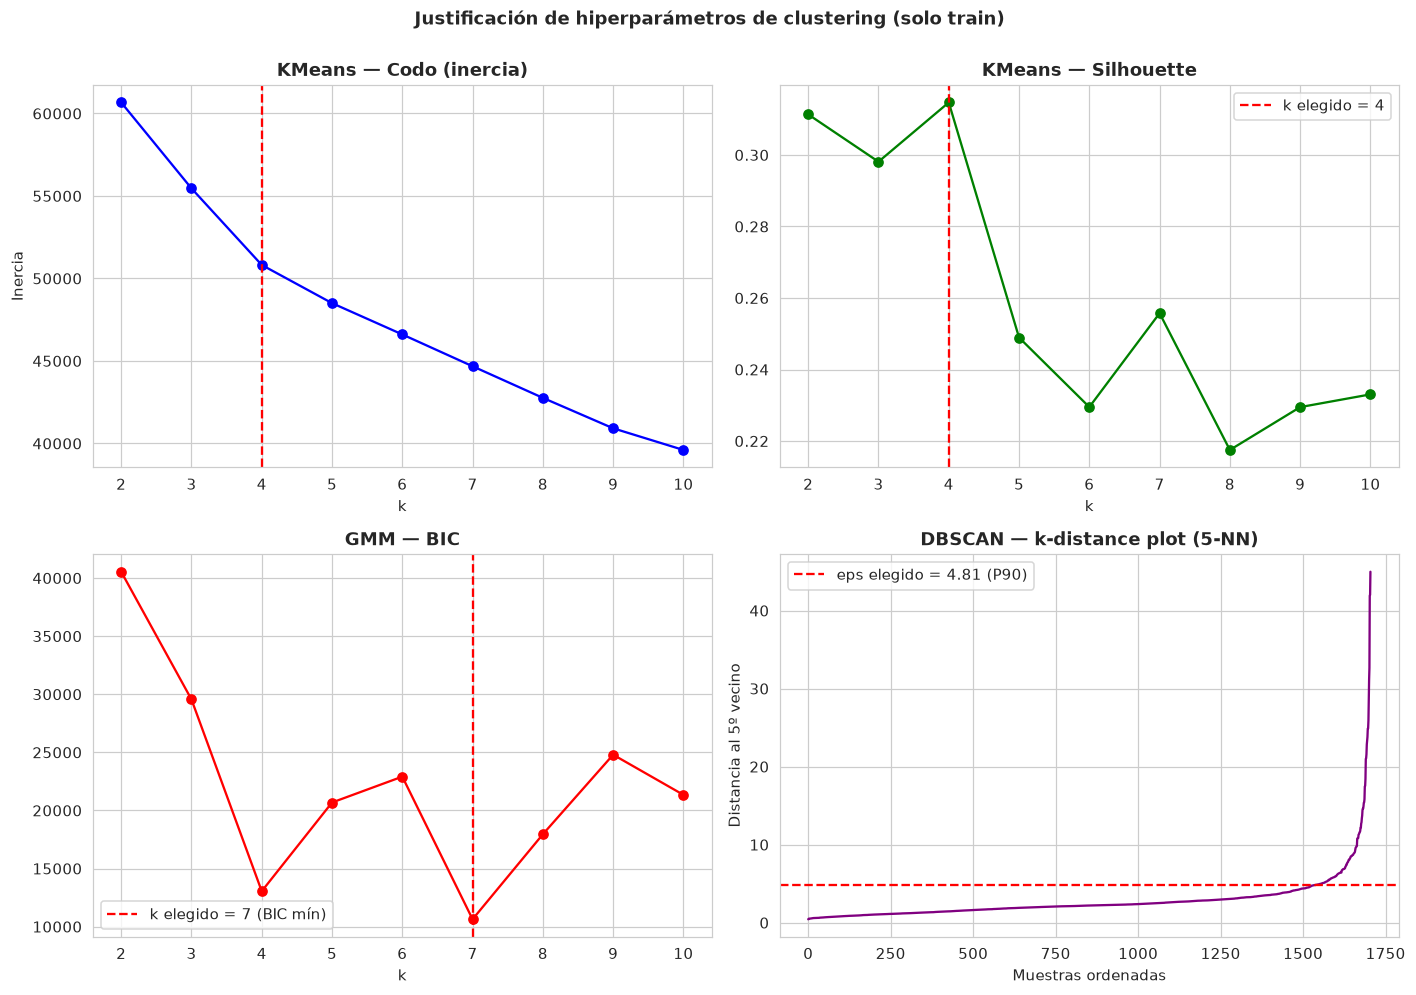

KMeans k=4 | GMM k=7 | DBSCAN eps=4.81, min_samples=5


In [7]:
SC_CLU = StandardScaler().fit(X_train)          # scaler SOLO para clustering
Xtr_sc = SC_CLU.transform(X_train)
Xte_sc = SC_CLU.transform(X_test)

# --- KMeans: codo + silhouette (k=2..10) ---
ks = range(2, 11)
inercias, silus = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xtr_sc)
    inercias.append(km.inertia_)
    silus.append(silhouette_score(Xtr_sc, km.labels_))
K_KMEANS = list(ks)[int(np.argmax(silus))]

# --- GMM: BIC (k=2..10) ---
bics = []
for k in ks:
    gm = GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(Xtr_sc)
    bics.append(gm.bic(Xtr_sc))
K_GMM = list(ks)[int(np.argmin(bics))]

# --- DBSCAN: k-distance plot (k=5) ---
nn5 = NearestNeighbors(n_neighbors=5).fit(Xtr_sc)
d5 = np.sort(nn5.kneighbors(Xtr_sc)[0][:, -1])
EPS = float(np.percentile(d5, 90))   # codo aproximado: percentil 90 de la 5-NN distance

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].plot(list(ks), inercias, marker='o', color='blue')
axes[0,0].axvline(K_KMEANS, ls='--', color='red'); axes[0,0].set_title('KMeans — Codo (inercia)', fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia')
axes[0,1].plot(list(ks), silus, marker='o', color='green')
axes[0,1].axvline(K_KMEANS, ls='--', color='red', label=f'k elegido = {K_KMEANS}')
axes[0,1].set_title('KMeans — Silhouette', fontweight='bold'); axes[0,1].set_xlabel('k'); axes[0,1].legend()
axes[1,0].plot(list(ks), bics, marker='o', color='red')
axes[1,0].axvline(K_GMM, ls='--', color='red', label=f'k elegido = {K_GMM} (BIC mín)')
axes[1,0].set_title('GMM — BIC', fontweight='bold'); axes[1,0].set_xlabel('k'); axes[1,0].legend()
axes[1,1].plot(d5, color='purple')
axes[1,1].axhline(EPS, ls='--', color='red', label=f'eps elegido = {EPS:.2f} (P90)')
axes[1,1].set_title('DBSCAN — k-distance plot (5-NN)', fontweight='bold')
axes[1,1].set_xlabel('Muestras ordenadas'); axes[1,1].set_ylabel('Distancia al 5º vecino'); axes[1,1].legend()
plt.suptitle('Justificación de hiperparámetros de clustering (solo train)', fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig('outputs_sprint2/clustering_justificacion.png', bbox_inches='tight'); plt.show()
print(f'KMeans k={K_KMEANS} | GMM k={K_GMM} | DBSCAN eps={EPS:.2f}, min_samples=5')

In [8]:
# Ajuste final de los 3 metodos en TRAIN y derivacion de features para train y test
KM = KMeans(n_clusters=K_KMEANS, random_state=SEED, n_init=10).fit(Xtr_sc)
GM = GaussianMixture(n_components=K_GMM, random_state=SEED, n_init=3).fit(Xtr_sc)
DB = DBSCAN(eps=EPS, min_samples=5).fit(Xtr_sc)

# DBSCAN no tiene predict: en test, outlier = distancia al core sample mas cercano > eps
cores = Xtr_sc[DB.core_sample_indices_]
nn_core = NearestNeighbors(n_neighbors=1).fit(cores)

def features_clustering(Xsc):
    d_km = KM.transform(Xsc)
    return pd.DataFrame({
        'kmeans_label': KM.predict(Xsc),
        'kmeans_dist':  d_km.min(axis=1),
        'gmm_label':    GM.predict(Xsc),
        'gmm_prob_max': GM.predict_proba(Xsc).max(axis=1),
        'dbscan_outlier': (nn_core.kneighbors(Xsc)[0][:, 0] > EPS).astype(int),
    })

CLU_TRAIN = features_clustering(Xtr_sc).set_index(X_train.index)
CLU_TEST  = features_clustering(Xte_sc).set_index(X_test.index)
FEATURES_CLU = list(CLU_TRAIN.columns)
print('Features de clustering:', FEATURES_CLU)
print(f"Outliers DBSCAN — train: {CLU_TRAIN['dbscan_outlier'].mean():.1%} | test: {CLU_TEST['dbscan_outlier'].mean():.1%}")

Features de clustering: ['kmeans_label', 'kmeans_dist', 'gmm_label', 'gmm_prob_max', 'dbscan_outlier']
Outliers DBSCAN — train: 7.2% | test: 10.1%


In [10]:
comp = []
for col in ['kmeans_label', 'gmm_label', 'dbscan_outlier']:
    t = pd.crosstab(CLU_TRAIN[col], y_train, normalize='index')
    t.columns = ['% Neg', '% Pos']
    t.insert(0, 'n', pd.crosstab(CLU_TRAIN[col], y_train).sum(axis=1))
    t.index = [f'{col}={i}' for i in t.index]
    comp.append(t)
tabla_comp = pd.concat(comp).round(3)
tabla_comp.to_csv('outputs_sprint2/clustering_composicion.csv')
print(f'Composición del target por cluster (train) — tasa base de positivos: {y_train.mean():.3f}')
tabla_comp

Composición del target por cluster (train) — tasa base de positivos: 0.122


,n,% Neg,% Pos
kmeans_label=0,809,0.791,0.209
kmeans_label=1,22,0.500,0.500
kmeans_label=2,278,0.986,0.014
kmeans_label=3,596,0.960,0.040
gmm_label=0,789,0.971,0.029
gmm_label=1,80,0.562,0.438
gmm_label=2,229,0.943,0.057
gmm_label=3,169,0.580,0.420
gmm_label=4,422,0.865,0.135
gmm_label=5,2,0.000,1.000


## Experimentos A/B

In [11]:
SETS = {
    'E1 Baseline':   (X_train,                                   X_test),
    'E2 +FE':        (X_train_fe,                                X_test_fe),
    'E3 +Cluster':   (pd.concat([X_train, CLU_TRAIN], axis=1),   pd.concat([X_test, CLU_TEST], axis=1)),
    'E4 +FE+Clu':    (pd.concat([X_train_fe, CLU_TRAIN], axis=1),pd.concat([X_test_fe, CLU_TEST], axis=1)),
}
EXPERIMENTOS = list(SETS)
res_ab = {}
f1_ab = pd.DataFrame(index=EXPERIMENTOS, columns=MODELOS, dtype=float)
for exp, (Xtr_s, Xte_s) in SETS.items():
    for mod in MODELOS:
        r = entrenar_evaluar(mod, Xtr_s, y_train, Xte_s, y_test)
        res_ab[(exp, mod)] = r
        f1_ab.loc[exp, mod] = r['F1']
f1_ab = f1_ab.astype(float).round(4)
f1_ab.to_csv('outputs_sprint2/experimentos_f1.csv')
MEJOR_SET = {mod: f1_ab[mod].idxmax() for mod in MODELOS}

def resaltar_maximo(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('F1 (hold-out) por experimento y modelo:')
display(f1_ab.style.apply(resaltar_maximo, axis=0).format('{:.4f}'))
print('Mejor set de features por modelo:', MEJOR_SET)

F1 (hold-out) por experimento y modelo:


,Random Forest,XGBoost
E1 Baseline,0.7241,0.7523
E2 +FE,0.7288,0.7429
E3 +Cluster,0.7130,0.7568
E4 +FE+Clu,0.7179,0.7048


Mejor set de features por modelo: {'Random Forest': 'E2 +FE', 'XGBoost': 'E3 +Cluster'}


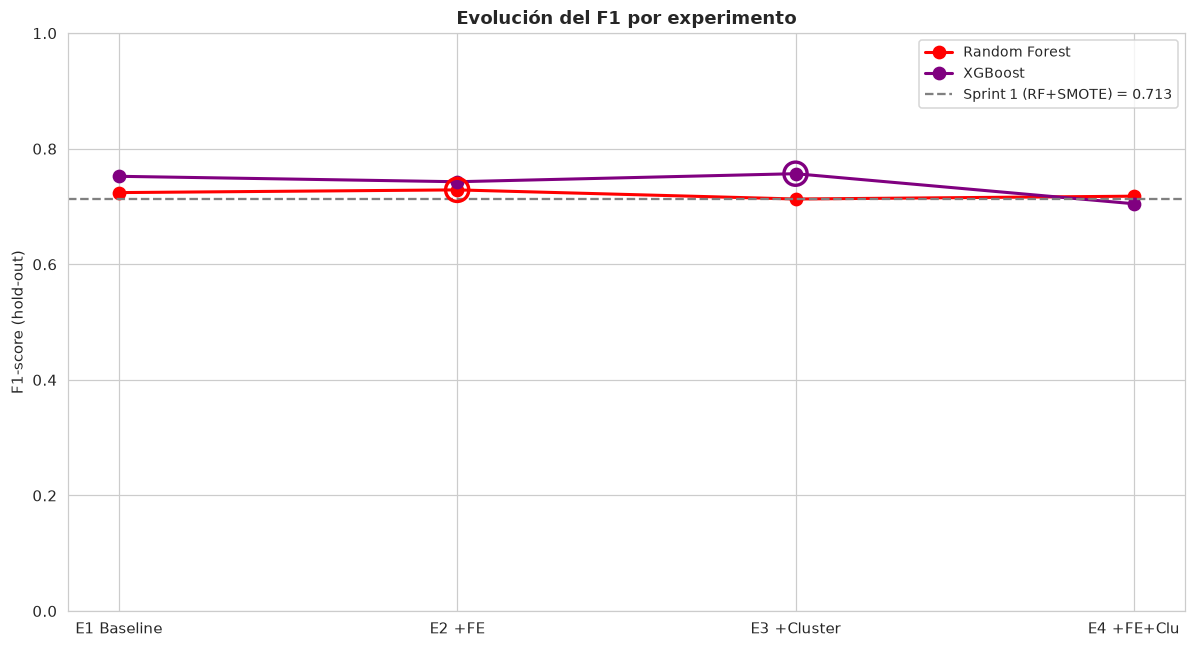

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(EXPERIMENTOS))
for mod in MODELOS:
    ax.plot(x, f1_ab[mod].values, marker='o', lw=2, markersize=8, color=MODEL_COLORS[mod], label=mod)
    xi = EXPERIMENTOS.index(MEJOR_SET[mod])
    ax.scatter([xi], [f1_ab.loc[MEJOR_SET[mod], mod]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.axhline(F1_SPRINT1, ls='--', color='gray', label=f'Sprint 1 (RF+SMOTE) = {F1_SPRINT1:.3f}')
ax.set_xticks(x); ax.set_xticklabels(EXPERIMENTOS)
ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, 1)
ax.set_title('Evolución del F1 por experimento', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint2/exp_evolucion_f1.png', bbox_inches='tight'); plt.show()

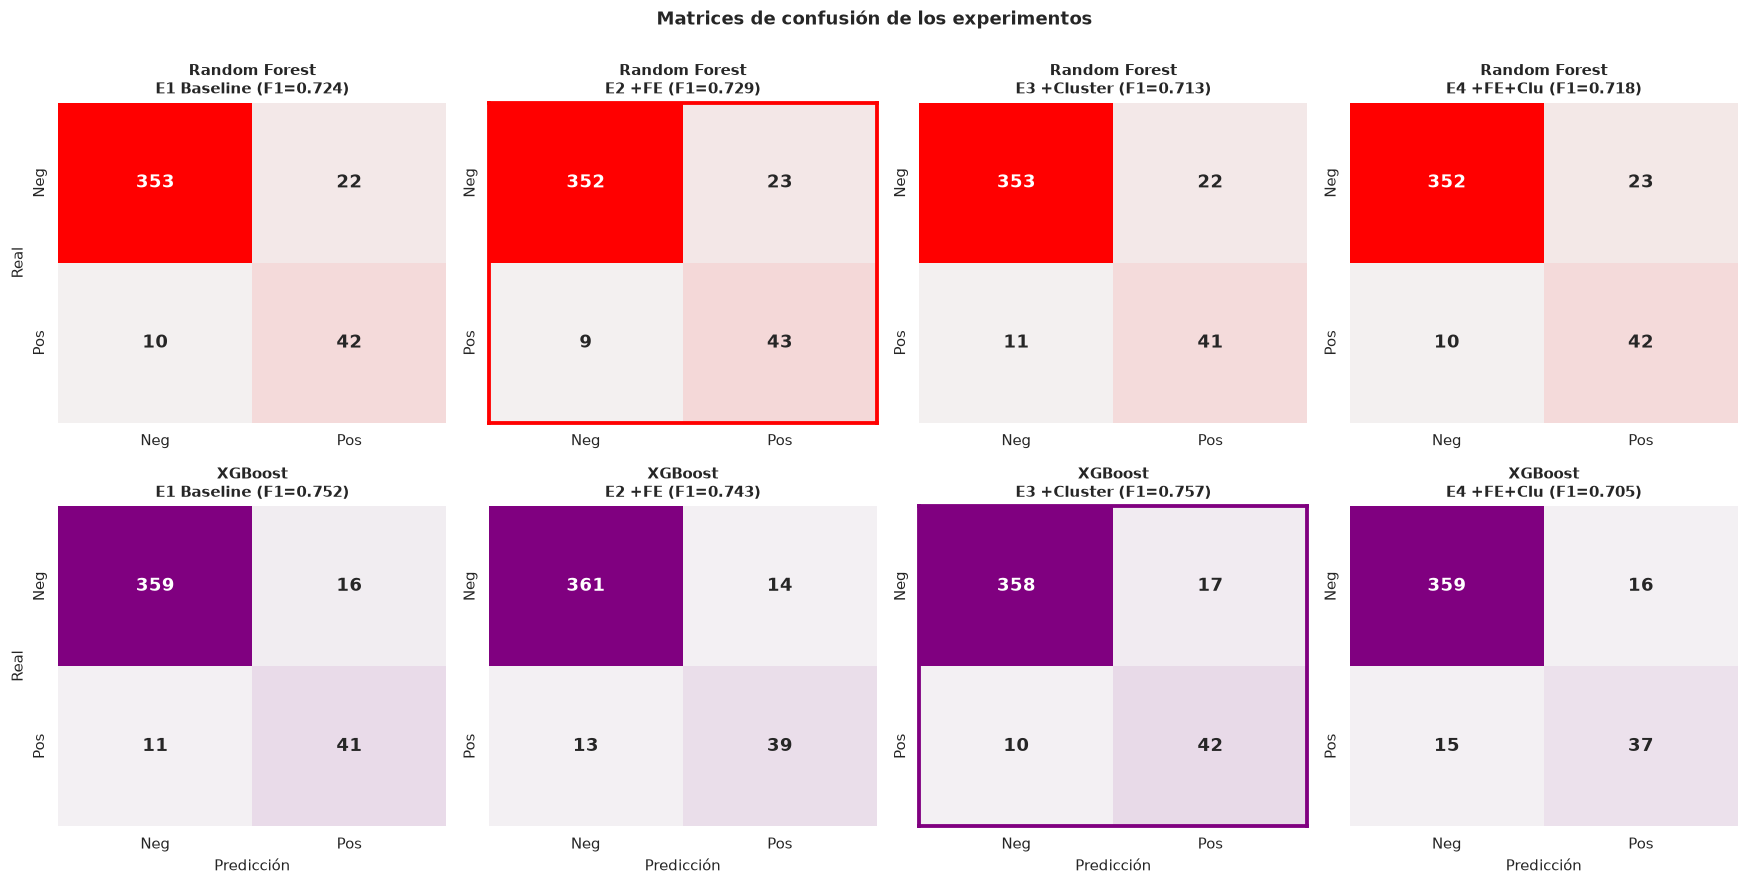

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, mod in enumerate(MODELOS):
    for j, exp in enumerate(EXPERIMENTOS):
        ax = axes[i, j]
        r = res_ab[(exp, mod)]
        cm = confusion_matrix(y_test, r['_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                    cmap=sns.light_palette(MODEL_COLORS[mod], as_cmap=True),
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                    annot_kws={'size': 12, 'fontweight': 'bold'})
        borde = 2.5 if exp == MEJOR_SET[mod] else 0
        if borde:
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_linewidth(borde); sp.set_color(MODEL_COLORS[mod])
        ax.set_title(f'{mod}\n{exp} (F1={r["F1"]:.3f})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicción' if i == 1 else ''); ax.set_ylabel('Real' if j == 0 else '')
plt.suptitle('Matrices de confusión de los experimentos',
             fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig('outputs_sprint2/exp_matrices_confusion.png', bbox_inches='tight'); plt.show()

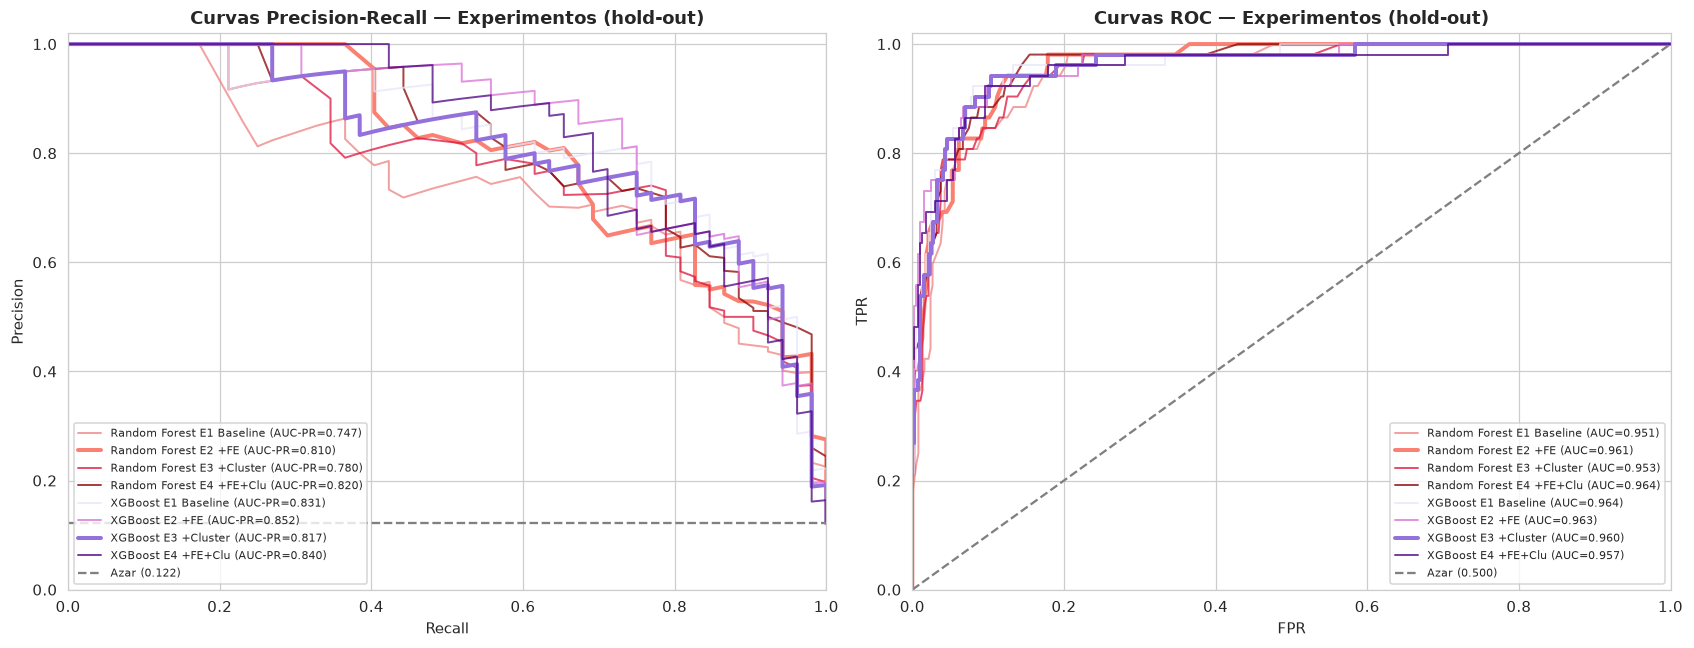

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))
for mod in MODELOS:
    for j, exp in enumerate(EXPERIMENTOS):
        prob = res_ab[(exp, mod)]['_prob']
        es_mejor = (exp == MEJOR_SET[mod])
        lw = 2.6 if es_mejor else 1.3
        alpha = 1.0 if es_mejor else 0.75
        color = EXP_COLORS[mod][j]
        p, r, _ = precision_recall_curve(y_test, prob)
        axes[0].plot(r, p, color=color, lw=lw, alpha=alpha,
                     label=f'{mod} {exp} (AUC-PR={auc(r, p):.3f})')
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[1].plot(fpr, tpr, color=color, lw=lw, alpha=alpha,
                     label=f'{mod} {exp} (AUC={roc_auc_score(y_test, prob):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curvas Precision-Recall — Experimentos (hold-out)', fontweight='bold')
axes[0].legend(fontsize=7.5, loc='lower left')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curvas ROC — Experimentos (hold-out)', fontweight='bold')
axes[1].legend(fontsize=7.5, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint2/exp_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Optuna

In [19]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def f1_cv(nombre, clf_factory, Xtr_s):
    '''F1 medio en CV 5-fold sobre train; balanceo SMOTE dentro del fold solo para RF.'''
    Xv = Xtr_s.values; yv = y_train.values
    f1s = []
    for tr_idx, va_idx in CV.split(Xv, yv):
        Xtr_f, ytr_f = Xv[tr_idx], yv[tr_idx]
        if nombre == 'Random Forest':
            Xtr_f, ytr_f = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(Xtr_f, ytr_f)
        clf = clf_factory()
        clf.fit(Xtr_f, ytr_f)
        f1s.append(f1_score(yv[va_idx], clf.predict(Xv[va_idx])))
    return float(np.mean(f1s))

def objective_rf(trial, Xtr_s):
    p = {'n_estimators': trial.suggest_int('n_estimators', 100, 600),
         'max_depth': trial.suggest_int('max_depth', 4, 30),
         'min_samples_split': trial.suggest_int('min_samples_split', 2, 12),
         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5])}
    return f1_cv('Random Forest',
                 lambda: RandomForestClassifier(random_state=SEED, n_jobs=-1, **p), Xtr_s)

def objective_xgb(trial, Xtr_s):
    p = {'n_estimators': trial.suggest_int('n_estimators', 100, 700),
         'max_depth': trial.suggest_int('max_depth', 3, 12),
         'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
         'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
         'gamma': trial.suggest_float('gamma', 0, 5),
         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0)}
    return f1_cv('XGBoost',
                 lambda: xgb.XGBClassifier(random_state=SEED, eval_metric='logloss',
                                           tree_method='hist', n_jobs=-1, **p), Xtr_s)

studies, best_params = {}, {}
for mod, obj in [('Random Forest', objective_rf), ('XGBoost', objective_xgb)]:
    Xtr_s = SETS[MEJOR_SET[mod]][0]
    t0 = time.time()
    st = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    st.optimize(lambda tr: obj(tr, Xtr_s), n_trials=50, show_progress_bar=False)
    studies[mod] = st; best_params[mod] = st.best_params
    print(f'{mod} [{MEJOR_SET[mod]}] → mejor F1 CV = {st.best_value:.4f} '
          f'({time.time()-t0:.0f}s, {len(st.trials)} trials)')
    print('  params:', st.best_params)
with open('outputs_sprint2/optuna_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

Random Forest [E2 +FE] → mejor F1 CV = 0.7074 (1079s, 50 trials)
  params: {'n_estimators': 433, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
XGBoost [E3 +Cluster] → mejor F1 CV = 0.7413 (213s, 50 trials)
  params: {'n_estimators': 621, 'max_depth': 8, 'learning_rate': 0.1541185187401039, 'subsample': 0.7519849993125656, 'colsample_bytree': 0.6371813393472459, 'min_child_weight': 5.018676254615216, 'gamma': 1.6037212936460654, 'scale_pos_weight': 3.7428233723633557}


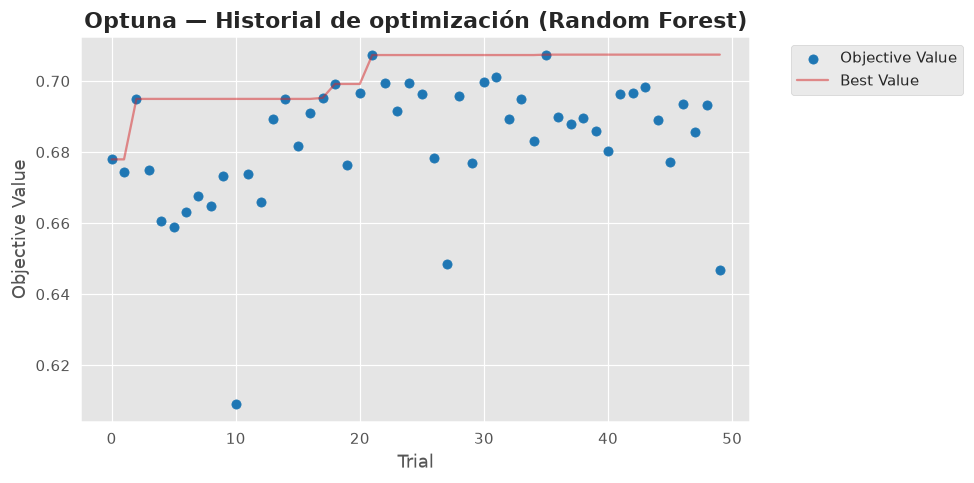

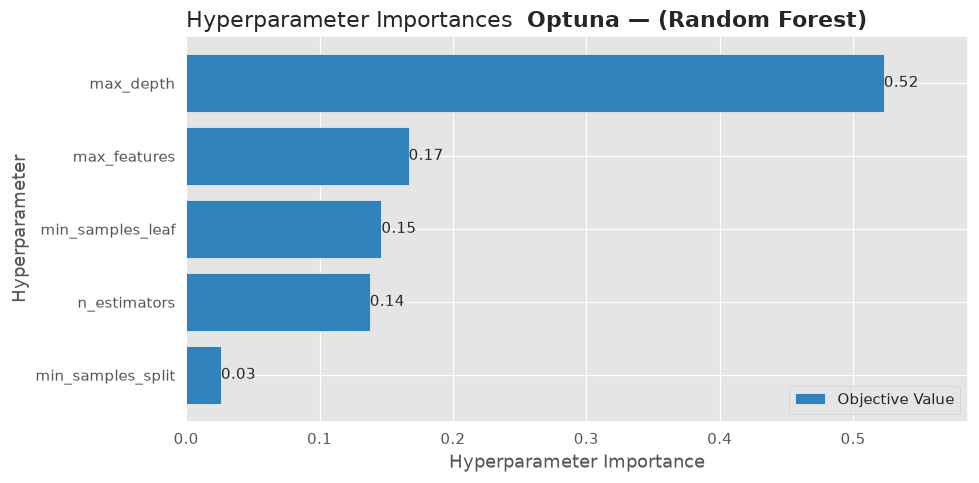

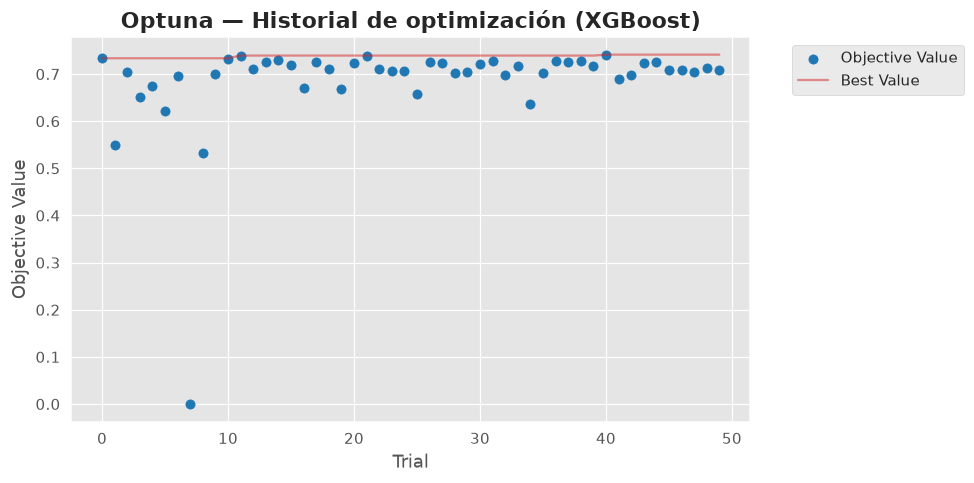

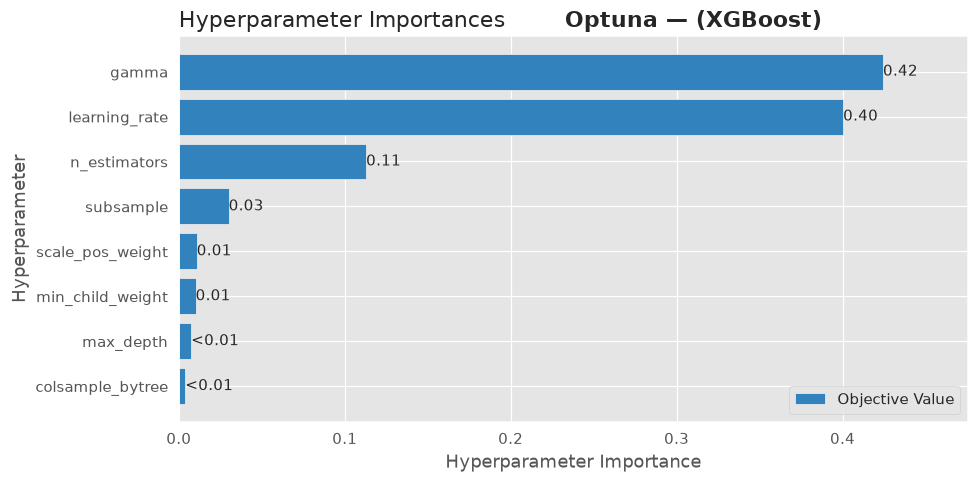

In [26]:
from optuna.visualization.matplotlib import (plot_optimization_history,
                                              plot_param_importances)
for mod in MODELOS:
    tag = mod.replace(' ', '')
    ax = plot_optimization_history(studies[mod])
    ax.set_title(f'Optuna — Historial de optimización ({mod})', fontweight='bold')
    plt.gcf().set_size_inches(9, 4.5); plt.tight_layout()
    plt.savefig(f'outputs_sprint2/optuna_historial_{tag}.png', bbox_inches='tight'); plt.show()

    ax = plot_param_importances(studies[mod])
    ax.set_title(f'                              Optuna — ({mod})', fontweight='bold')
    plt.gcf().set_size_inches(9, 4.5); plt.tight_layout()
    plt.savefig(f'outputs_sprint2/optuna_importancia_{tag}.png', bbox_inches='tight'); plt.show()

In [27]:
def clf_optimizado(mod):
    p = best_params[mod].copy()
    if mod == 'Random Forest':
        return RandomForestClassifier(random_state=SEED, n_jobs=-1, **p)
    return xgb.XGBClassifier(random_state=SEED, eval_metric='logloss',
                             tree_method='hist', n_jobs=-1, **p)

res_optuna = {}
for mod in MODELOS:
    Xtr_s, Xte_s = SETS[MEJOR_SET[mod]]
    res_optuna[mod] = entrenar_evaluar(mod, Xtr_s, y_train, Xte_s, y_test, clf=clf_optimizado(mod))
    print(f"{mod} + Optuna [{MEJOR_SET[mod]}] → F1 hold-out = {res_optuna[mod]['F1']:.4f}")

Random Forest + Optuna [E2 +FE] → F1 hold-out = 0.7119
XGBoost + Optuna [E3 +Cluster] → F1 hold-out = 0.8036


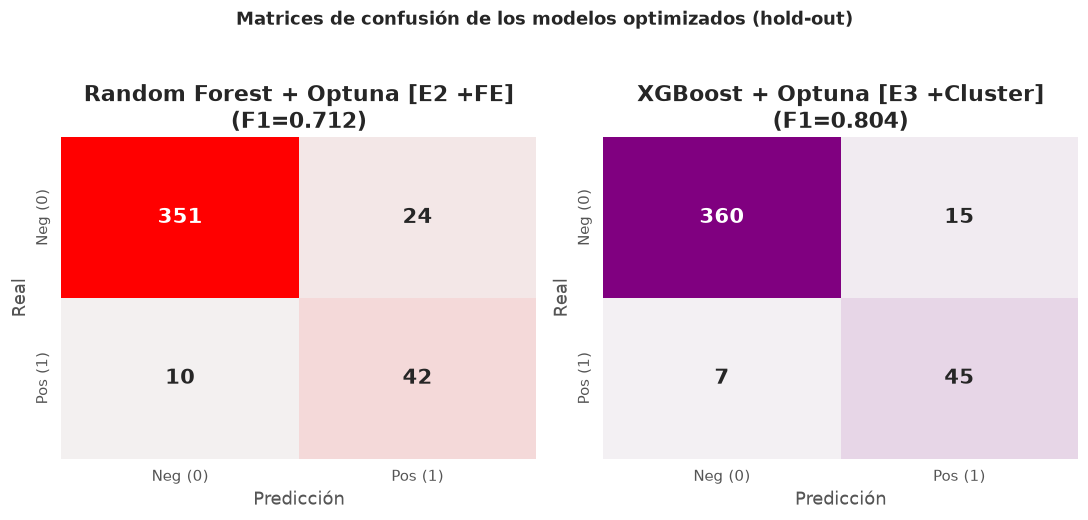

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, mod in zip(axes, MODELOS):
    r = res_optuna[mod]
    cm = confusion_matrix(y_test, r['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                cmap=sns.light_palette(MODEL_COLORS[mod], as_cmap=True),
                xticklabels=['Neg (0)', 'Pos (1)'], yticklabels=['Neg (0)', 'Pos (1)'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{mod} + Optuna [{MEJOR_SET[mod]}]\n(F1={r["F1"]:.3f})', fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión de los modelos optimizados (hold-out)',
             fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs_sprint2/optuna_matrices_confusion.png', bbox_inches='tight'); plt.show()

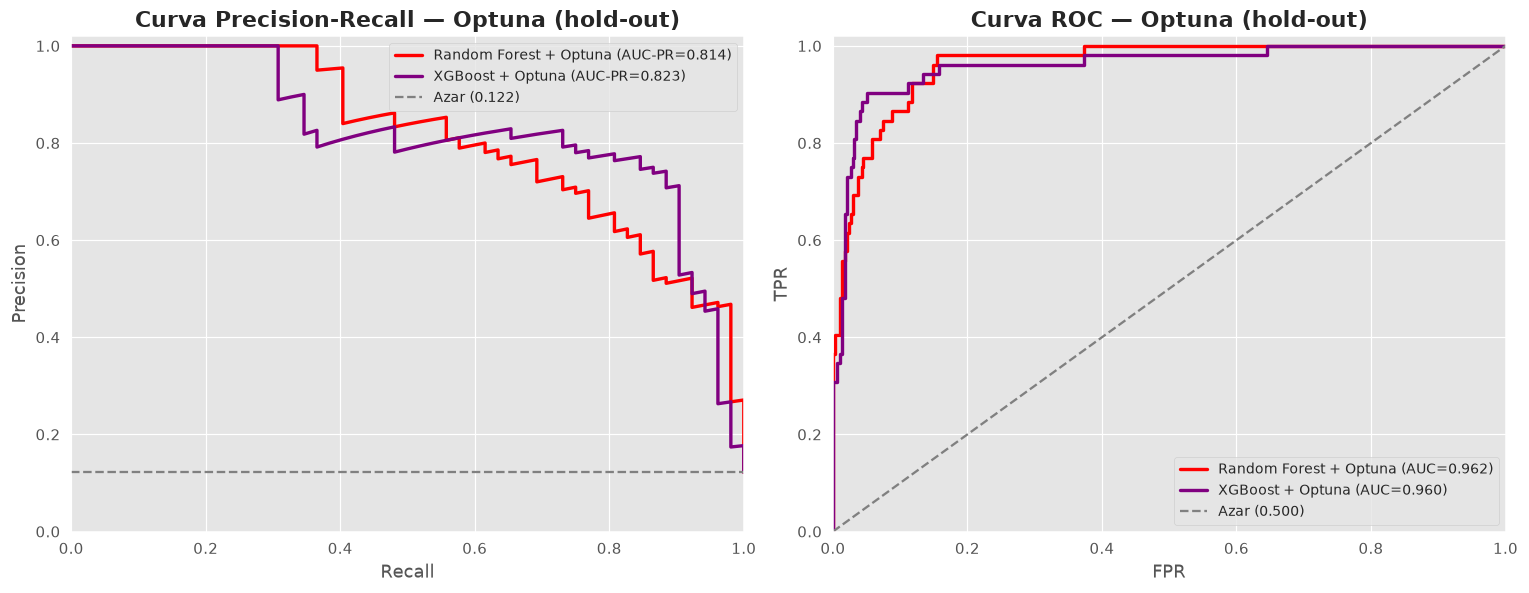

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for mod in MODELOS:
    prob = res_optuna[mod]['_prob']
    p, r, _ = precision_recall_curve(y_test, prob)
    axes[0].plot(r, p, color=MODEL_COLORS[mod], lw=2.2,
                 label=f'{mod} + Optuna (AUC-PR={auc(r, p):.3f})')
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, color=MODEL_COLORS[mod], lw=2.2,
                 label=f'{mod} + Optuna (AUC={roc_auc_score(y_test, prob):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curva Precision-Recall — Optuna (hold-out)', fontweight='bold'); axes[0].legend(fontsize=9)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva ROC — Optuna (hold-out)', fontweight='bold'); axes[1].legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint2/optuna_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Tabla comparativa

In [30]:
etapas_f1 = []
mejor_cfg_final = {}
for mod in MODELOS:
    f1_e1 = f1_ab.loc['E1 Baseline', mod]
    f1_ab_best = f1_ab.loc[MEJOR_SET[mod], mod]
    f1_opt = res_optuna[mod]['F1']
    mejor_cfg_final[mod] = 'Mejor experimento' if f1_ab_best >= f1_opt else '+ Optuna'
    etapas_f1.append({'Modelo': mod, 'E1 Baseline': round(f1_e1, 4),
                      f'Mejor experimento': round(f1_ab_best, 4),
                      'Set': MEJOR_SET[mod], '+ Optuna': round(f1_opt, 4),
                      'Mejor F1 final': round(max(f1_ab_best, f1_opt), 4),
                      'Config final': mejor_cfg_final[mod],
                      'Δ vs E1': round(max(f1_ab_best, f1_opt) - f1_e1, 4)})
tabla_f1 = pd.DataFrame(etapas_f1).set_index('Modelo')
tabla_f1.to_csv('outputs_sprint2/tabla_comparativa_f1.csv')
print('Antes/después — F1 (hold-out):')
display(tabla_f1)

Antes/después — F1 (hold-out):


,E1 Baseline,Mejor experimento,Set,+ Optuna,Mejor F1 final,Config final,Δ vs E1
Modelo,,,,,,,
Random Forest,0.7241,0.7288,E2 +FE,0.7119,0.7288,Mejor experimento,0.0047
XGBoost,0.7523,0.7568,E3 +Cluster,0.8036,0.8036,+ Optuna,0.0513


In [31]:
METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC']

def resultado_final(mod):
    return res_ab[(MEJOR_SET[mod], mod)] if mejor_cfg_final[mod] == 'Mejor experimento' \
           else res_optuna[mod]

filas = []
for mod in MODELOS:
    antes = res_ab[('E1 Baseline', mod)]
    desp = resultado_final(mod)
    for met in METRICAS:
        filas.append({'Modelo': mod,
                      'Config final': f'{mejor_cfg_final[mod]} [{MEJOR_SET[mod]}]',
                      'Métrica': met,
                      'Antes (E1)': round(antes[met], 4),
                      'Después': round(desp[met], 4),
                      'Δ': round(desp[met] - antes[met], 4)})
tabla_todas = pd.DataFrame(filas)
tabla_todas.to_csv('outputs_sprint2/tabla_comparativa_todas.csv', index=False)
display(tabla_todas.pivot_table(index=['Modelo', 'Config final'], columns='Métrica',
        values=['Antes (E1)', 'Después', 'Δ']).round(4))

Antes (E1)                   \
Métrica                                     AUC-ROC Accuracy      F1   
Modelo        Config final                                             
Random Forest Mejor experimento [E2 +FE]     0.9506   0.9251  0.7241   
XGBoost       + Optuna [E3 +Cluster]         0.9636   0.9368  0.7523   

                                                           Después           \
Métrica                                  Precision  Recall AUC-ROC Accuracy   
Modelo        Config final                                                    
Random Forest Mejor experimento [E2 +FE]    0.6562  0.8077  0.9613   0.9251   
XGBoost       + Optuna [E3 +Cluster]        0.7193  0.7885  0.9596   0.9485   

                                                                         Δ  \
Métrica                                       F1 Precision  Recall AUC-ROC   
Modelo        Config final                                                   
Random Forest Mejor experimento [E2 +FE]  0.7288    0.6515  0.8269  0.0107   
XGBoost       + Optuna [E3 +Cluster]      0.8036    0.7500  0.8654 -0.0039   

                                                                             
Métrica                                  Accuracy      F1 Precision  Recall  
Modelo        Config final                                                   
Random Forest Mejor experimento [E2 +FE]   0.0000  0.0047   -0.0047  0.0192  
XGBoost       + Optuna [E3 +Cluster]       0.0117  0.0513    0.0307  0.0769

## Resumen

In [33]:
mejor_modelo_global = max(MODELOS, key=lambda m: resultado_final(m)['F1'])
res_ganador = resultado_final(mejor_modelo_global)
Xtr_s = SETS[MEJOR_SET[mejor_modelo_global]][0]
importancias = pd.Series(res_ganador['_clf'].feature_importances_, index=Xtr_s.columns)\
                 .sort_values(ascending=False)
importancias.to_csv('outputs_sprint2/mejor_modelo_importancias.csv', header=['importancia'])

resumen = {'mejor_modelo': mejor_modelo_global,
           'mejor_set': MEJOR_SET[mejor_modelo_global],
           'config_final': mejor_cfg_final[mejor_modelo_global],
           'f1_final': round(res_ganador['F1'], 4),
           'f1_sprint1': F1_SPRINT1,
           'mejora_vs_sprint1': round(res_ganador['F1'] - F1_SPRINT1, 4),
           'best_params_optuna': best_params[mejor_modelo_global]}
with open('outputs_sprint2/resumen_sprint2.json', 'w') as f:
    json.dump(resumen, f, indent=2)

print('════════════ RESUMEN SPRINT 2 ════════════')
print(f'Resultado de FE y clustering')
for mod in MODELOS:
    delta = f1_ab.loc[MEJOR_SET[mod], mod] - f1_ab.loc['E1 Baseline', mod]
    print(f'  {mod}: E1={f1_ab.loc["E1 Baseline", mod]:.4f} → {MEJOR_SET[mod]}='
          f'{f1_ab.loc[MEJOR_SET[mod], mod]:.4f} (Δ={delta:+.4f})')
print(f'\nMejor modelo')
print(f'  GANADOR: {mejor_modelo_global} ({mejor_cfg_final[mejor_modelo_global]}, '
      f'{MEJOR_SET[mejor_modelo_global]}) → F1 = {res_ganador["F1"]:.4f}')
print(f'  Evolución del proyecto: Sprint 1 = {F1_SPRINT1:.4f} → Sprint 2 = '
      f'{res_ganador["F1"]:.4f} ({res_ganador["F1"]-F1_SPRINT1:+.4f})')
print('\nTop-15 features más importantes:')
display(importancias.head(15).round(4).to_frame('importancia'))

════════════ RESUMEN SPRINT 2 ════════════
Resultado de FE y clustering
  Random Forest: E1=0.7241 → E2 +FE=0.7288 (Δ=+0.0047)
  XGBoost: E1=0.7523 → E3 +Cluster=0.7568 (Δ=+0.0045)

Mejor modelo
  GANADOR: XGBoost (+ Optuna, E3 +Cluster) → F1 = 0.8036
  Evolución del proyecto: Sprint 1 = 0.7130 → Sprint 2 = 0.8036 (+0.0906)

Top-15 features más importantes:


,importancia
Ag_ppm,0.1007
Sb_ppm,0.0605
Ce_ppm,0.0408
Ta_ppm,0.0383
Te_ppm,0.0333
Mg_per,0.0328
Na_per,0.0303
As_ppm,0.0260
Ga_ppm,0.0240
Mo_ppm,0.0229
